# Librerías

In [ ]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Semilla

In [2]:
SEED = 42

random.seed(SEED)

# Cargar archivos

In [3]:
DATA_PATH = "data"

annotations = pd.read_csv(
    os.path.join(DATA_PATH, "annotations.csv")
)

candidates = pd.read_csv(
    os.path.join(DATA_PATH, "candidates.csv")
)

# Obtener todas las tomografías

In [4]:
all_seriesuid = set(
    candidates["seriesuid"]
)

# Separar CT

In [5]:
ct_positive = set(
    annotations["seriesuid"]
)

ct_negative = all_seriesuid - ct_positive

print(f"CT con nódulo : {len(ct_positive)}")
print(f"CT sin nódulo : {len(ct_negative)}")

CT con nódulo : 601
CT sin nódulo : 287


# Train / Validation / Test

In [6]:
train_pos, temp_pos = train_test_split(
    list(ct_positive),
    test_size=0.30,
    random_state=SEED
)

val_pos, test_pos = train_test_split(
    temp_pos,
    test_size=0.50,
    random_state=SEED
)

In [7]:
train_neg, temp_neg = train_test_split(
    list(ct_negative),
    test_size=0.30,
    random_state=SEED
)

val_neg, test_neg = train_test_split(
    temp_neg,
    test_size=0.50,
    random_state=SEED
)

In [8]:
train_ct = sorted(
    train_pos + train_neg
)

validation_ct = sorted(
    val_pos + val_neg
)

test_ct = sorted(
    test_pos + test_neg
)

In [13]:
print("TRAIN")
print(len(train_ct))
print("VALIDATION")
print(len(validation_ct))
print("TEST")
print(len(test_ct))

TRAIN
620
VALIDATION
133
TEST
135


In [ ]:
os.makedirs(
    "splits",
    exist_ok=True
)
with open(
    "splits/train.txt",
    "w"
) as f:

    for ct in train_ct:
        f.write(ct + "\n")
        
with open(
    "splits/validation.txt",
    "w"
) as f:

    for ct in validation_ct:
        f.write(ct + "\n")

with open(
    "splits/test.txt",
    "w"
) as f:

    for ct in test_ct:
        f.write(ct + "\n")

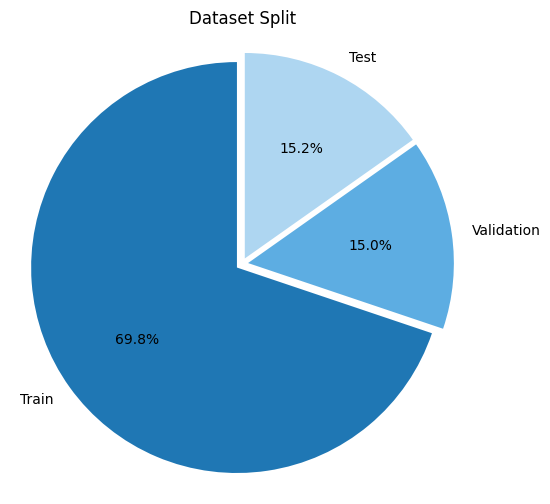

In [ ]:
labels = ["Train", "Validation", "Test"]

sizes = [
    len(train_ct),
    len(validation_ct),
    len(test_ct)
]

colors = [
    "#1f77b4",  # azul fuerte
    "#5DADE2",  # azul medio
    "#AED6F1"   # azul claro
]

explode = (0.03, 0.03, 0.03)

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode
)

plt.title("Dataset Split")
plt.axis("equal")

plt.show()